# Oscilador Armónico Amortiguado: Comparación de Modelos Predictivos con Clases FFNN y PINN

## *Modelo Físico*

In [ ]:
# Librerias utiles
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import imageio.v2 as imageio
from os import TMP_MAX

In [2]:
# Parámetros físicos
l0 = 0.25 # m
g = 9.81  # m/s^2
m = 1     # kg
b = 0.5     # Ns/m
k = 2    # N/m
tiempo_total = 20 # s
delta_T = 0.01 # s
t_datos = 0.5*tiempo_total

In [3]:
# Calculo de parámetros útiles
omega = np.sqrt(k/m)
seda  = b/(2*np.sqrt(m*k))
phi = np.arctan(-seda)
# Definir el vector de tiempo
t = np.arange(0, tiempo_total, delta_T)

print(f"omega = {omega}")
print(f"seda = {seda}")
print(f"phi = {phi}")
print(f"t_datos = {t_datos}")

omega = 1.4142135623730951
seda = 0.17677669529663687
phi = -0.17496904566568885
t_datos = 10.0


In [ ]:
# Calcular desplazamiento y posición
def desplazamiento(tiempo):
  despl = (g / omega**2) * (1 - np.exp(-seda * omega * tiempo)* np.cos(omega * tiempo + phi)/np.cos(phi))
  return despl

u = desplazamiento(t)
x = u + l0

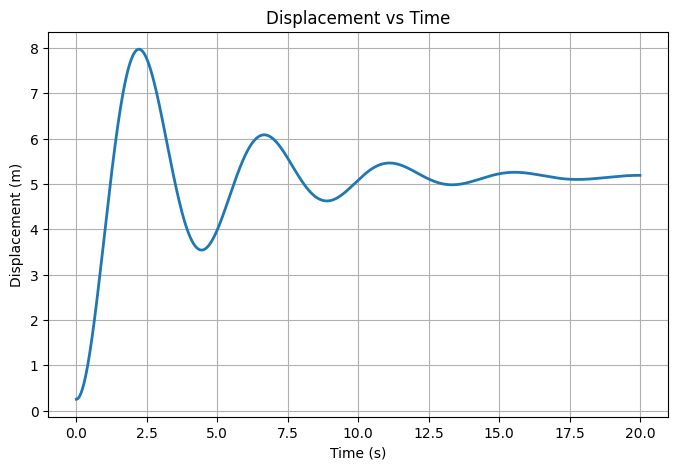

In [5]:
# Graficar
plt.figure(figsize=(8, 5))
plt.plot(t, x, linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.grid(True)
plt.title('Displacement vs Time')
plt.show()

## *Parámetros para Modelos Predictivos*

In [6]:
# Crear datos de entrada para la red neuronal
# X es un vector de n valores seleccionados entre 0 y 10
n = 25 # Numero de muestras
t_datos = 0.5*tiempo_total  # Tiempo de datos
t_max = t_datos  # Tiempo maximo
t_min = 0   # Tiempo minimo
X = np.arange(t_min, t_max, (t_max-t_min)/n)    # Vector de entrada
y = desplazamiento(X)   # Vector de salida
X_collocation = np.arange(0.0, tiempo_total, tiempo_total/100)  # Puntos de colisión
X_i = np.array([[0.0]]) # Condicion inicial de desplazamiento
b_init = np.array([[0.0]])  # Condicion inicial de velocidad

In [7]:
# Convertir a tensores de PyTorch
X_train = torch.tensor(X, dtype=torch.float32).reshape(-1, 1)
X_test  = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
y_train = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
y_test  = torch.tensor(u, dtype=torch.float32).reshape(-1, 1)
X_train_phy = torch.tensor(X_collocation, dtype=torch.float32).reshape(-1, 1)
X_init = torch.tensor(X_i, dtype=torch.float32).reshape(-1, 1)

In [ ]:
# Parametros de la Red Neuronal
epochs_FFNN = 10000
epochs_PINN = 50000
learning_rate = 1e-4
nneurons = 20
nhiden_layers = 25
activation_fn = nn.Tanh()
make_video = False

# Arquitectura de la red
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]
layers = np.array([input_dim] + [ nneurons for i in range(nhiden_layers)] + [output_dim])

## *Feed-Forward Neural Network (FFNN)*

### *Clase Deep Neural Network 🧠*

In [9]:
class DNN(nn.Module):

  # Inicialización de la RED
  def __init__(self, layers):
    super(DNN, self).__init__() # Llama __init__ de la clase padre

    # Funcion de activacion
    self.activation_fn = activation_fn

    # Historial de loss
    self.loss_history = []

    # Definir capas (crea una lista de capas Fully connected)
    self.layers = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

    # Inicializacion de pesos Xavier Glorot y bias como ceros
    for i in range(len(layers)-1):
      # Pesos
      nn.init.xavier_normal_(self.layers[i].weight.data, gain=1.0)
      # Bias
      nn.init.zeros_(self.layers[i].bias.data)

  # Propagación hacia adelante
  def forward(self, x):
    for i in range(len(layers)-2):
      x = self.activation_fn(self.layers[i](x))

    x = self.layers[-1](x)
    return x

### *Intanciar el modelo ⛏*

In [10]:
# Instanciar modelo, definir función de pérdida y optimizador
model_ffnn = DNN(layers)
loss_fn = nn.MSELoss(reduction = "mean")
optimizer = optim.Adam(model_ffnn.parameters(), lr=learning_rate)

### *Entrenar 🦾*

In [ ]:
# Entrenar el modelo
frames = [] # Lista para guardar imágenes

for epoch in range(epochs_FFNN):
  # Forward
  y_pred = model_ffnn(X_train)
  loss = loss_fn(y_pred, y_train)
  model_ffnn.loss_history.append(loss.item())

  # Backward
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch) % 10 == 0:
    print(f'Epoch [{epoch}/{epochs_FFNN}], Loss: {loss.item():.6f}')

    if make_video:
      # Haciendo plots para video
      y_pred = model_ffnn(X_test).detach().numpy()
      plt.figure(figsize=(8, 5))
      plt.plot(X_test[:, 0].numpy(), y_test.numpy(), label='Real', linewidth=1.5)
      plt.plot(X_test[:, 0].numpy(), y_pred, label='Predicho', linewidth=1.5, linestyle='dashed')
      # plot los puntos de evaluacion con X
      plt.scatter(X[:, 0], y, color='red', label='Puntos de evaluación', marker= 'x')
      plt.xlabel('Time (seda)')
      plt.ylabel('Displacement (m)')
      plt.legend()
      plt.title(f"Epoch {epoch}")
      plt.savefig(f"frame_{epoch}.png")
      plt.close()
      frames.append(imageio.imread(f"frame_{epoch}.png"))

if make_video:
  # Guardar el GIF
  gif_path = "training_animation.gif"
  imageio.mimsave(gif_path, frames, duration=0.5)
  files.download(gif_path)

Epoch [0/10000], Loss: 24.670918
Epoch [10/10000], Loss: 22.055408
Epoch [20/10000], Loss: 19.459450
Epoch [30/10000], Loss: 16.912748
Epoch [40/10000], Loss: 14.620739
Epoch [50/10000], Loss: 12.704441
Epoch [60/10000], Loss: 11.138451
Epoch [70/10000], Loss: 9.844816
Epoch [80/10000], Loss: 8.750962
Epoch [90/10000], Loss: 7.800147
Epoch [100/10000], Loss: 6.950351
Epoch [110/10000], Loss: 6.198672
Epoch [120/10000], Loss: 5.569800
Epoch [130/10000], Loss: 5.029696
Epoch [140/10000], Loss: 4.561519
Epoch [150/10000], Loss: 4.163576
Epoch [160/10000], Loss: 3.824209
Epoch [170/10000], Loss: 3.537131
Epoch [180/10000], Loss: 3.295171
Epoch [190/10000], Loss: 3.092159
Epoch [200/10000], Loss: 2.922587
Epoch [210/10000], Loss: 2.781511
Epoch [220/10000], Loss: 2.664557
Epoch [230/10000], Loss: 2.567868
Epoch [240/10000], Loss: 2.488039
Epoch [250/10000], Loss: 2.422051
Epoch [260/10000], Loss: 2.367166
Epoch [270/10000], Loss: 2.320760
Epoch [280/10000], Loss: 2.280005
Epoch [290/10000],

### *Evaluar resultados 📈*

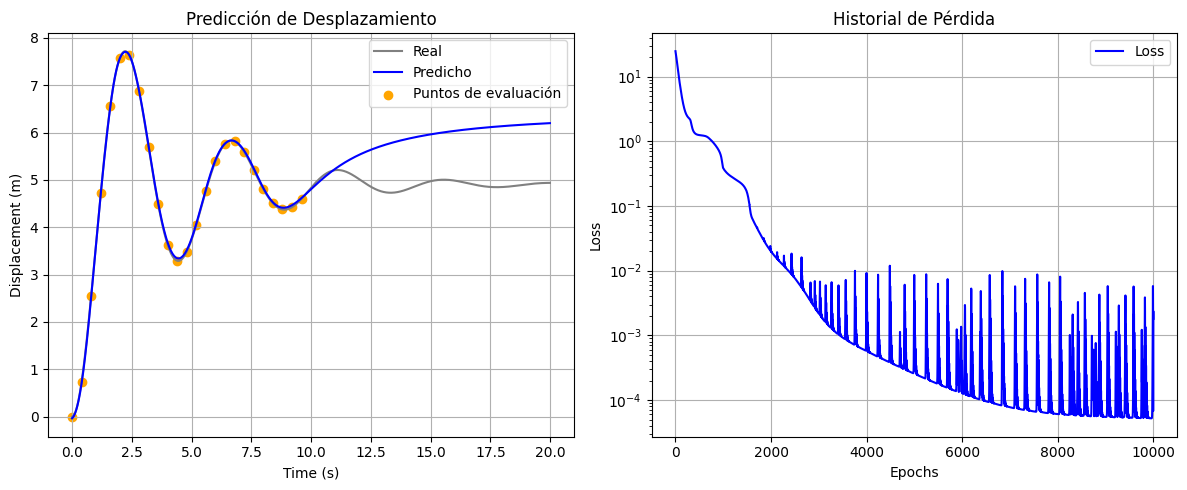

In [12]:
# Hacer predicciones
model_ffnn.eval()
y_pred = model_ffnn(X_test).detach().numpy()

# Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Predicción vs Real ---
axs[0].plot(X_test[:, 0].numpy(), y_test.numpy(), label='Real', linewidth=1.5, color = 'grey')
axs[0].plot(X_test[:, 0].numpy(), y_pred, label='Predicho', linewidth=1.5, color = 'blue')
axs[0].scatter(X_train[:, 0], y_train, color='orange', label='Puntos de evaluación', marker='o')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Displacement (m)')
axs[0].grid(True)
axs[0].set_title('Predicción de Desplazamiento')
axs[0].legend()

# --- Gráfico 2: Historial de pérdida ---
axs[1].semilogy(model_ffnn.loss_history, label='Loss', color='blue', linewidth=1.5)
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].grid(True)
axs[1].set_title('Historial de Pérdida')
axs[1].legend()

# Ajustar diseño para evitar superposiciones
plt.tight_layout()

# Mostrar los gráficos
plt.show()


## *Modelo Predictivo - Physics-Informed Neural Network (PINN)*

### *Clase PINN ⚛*

In [ ]:
class PINN():
  def __init__(self,layers):

    # funcion de perdida
    self.loss_fn = nn.MSELoss(reduction = "mean")

    # Inicializando iterador
    self.iter = 0

    # Inicializando la DNN
    self.dnn = DNN(layers)

    # Inicializando el historial de losses
    self.loss_history = {"Data":[],
                         "Physics":[],
                         "IC":[],
                         "Total":[],
                        }
  def loss_data(self, X, y):
    y_pred = self.dnn(X).reshape(-1,1)
    loss_data = self.loss_fn(y_pred, y)
    self.loss_history["Data"].append(loss_data.item())
    return loss_data

  def loss_physics(self, X_phy, X_init):
    # mg - k(x - l0) - b dx/dt - m ddx/ddt = 0
    # como la red toma X_phy (tiempo) y devuelve y_pred (desplazamiento)
    # Se tiene: x = y_pred + l0
    #           t = X_phy
    # Loss_phy = mg - k(y_pred) - b d(x)/d(X_phy) - m dd(x)/dd(X_phy)
    X_physics = X_phy.clone().requires_grad_(True)
    y_pred = self.dnn(X_physics).reshape(-1,1)
    u = y_pred

    # COMPLETAR ...
    du_dt = torch.autograd.grad(u, X_physics, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    ddu_ddt = torch.autograd.grad(du_dt, X_physics, torch.ones_like(du_dt), retain_graph=True, create_graph=True)[0]

    # Asumiendo que m, b, k, g están definidos (ej. self.m, self.b, etc.)
    # f = m*ddu/ddt + b*du/dt + k*u - mg
    f = m * ddu_ddt + b * du_dt + k * u - m * g

    # Calculamos la pérdida de física usando la MSELoss definida en __init__
    loss_physics = self.loss_fn(f, torch.zeros_like(f))
    # .............

    self.loss_history["Physics"].append(loss_physics.item())

    # En el instante inicial:
    # u(0) = 0
    # du/dt(0) = 0
    # ddu/ddt(0) = g(1-seda**2)
    X_initial = X_init.clone().requires_grad_(True)
    y_pred_init = self.dnn(X_initial).reshape(-1,1)
    u_init = y_pred_init

    # COMPLETAR ...
    du_dt_init = torch.autograd.grad(u_init, X_initial, torch.ones_like(u_init), retain_graph=True, create_graph=True)[0]
    ddu_ddt_init = torch.autograd.grad(du_dt_init, X_initial, torch.ones_like(du_dt_init), retain_graph=True, create_graph=True)[0]

    # Asumiendo que g y seda están definidos
    # Definir los valores objetivo para las CI
    target_u_init = torch.zeros_like(u_init)
    target_du_dt_init = torch.zeros_like(du_dt_init)
    target_ddu_ddt_init = torch.full_like(ddu_ddt_init, g * (1 - seda**2))

    # Pérdida para u(0) = 0
    loss_IC_term_1 = self.loss_fn(u_init, target_u_init)
    # Pérdida para du/dt(0) = 0
    loss_IC_term_2 = self.loss_fn(du_dt_init, target_du_dt_init)
    # Pérdida para ddu/ddt(0) = g(1-seda**2)
    loss_IC_term_3 = self.loss_fn(ddu_ddt_init, target_ddu_ddt_init)
    # .............

    loss_IC = loss_IC_term_1 + loss_IC_term_2 + loss_IC_term_3
    self.loss_history["IC"].append(loss_IC.item())

    return loss_physics, loss_IC


  def loss_total(self, X, y, X_phy, X_init):
    loss_data = self.loss_data(X, y)
    loss_physics, loss_IC = self.loss_physics(X_phy, X_init)
    loss_total = loss_data + loss_physics + loss_IC
    self.loss_history["Total"].append(loss_total.item())
    return loss_total, loss_data, loss_physics, loss_IC

### *Instanciar modelo ⛏*

In [14]:
# Instanciar modelo, definir función de pérdida y optimizador
model_pinn = PINN(layers)
loss_fn = nn.MSELoss(reduction = "mean")
optimizer = optim.Adam(model_pinn.dnn.parameters(), lr=learning_rate)

### *Entrenar 🦾*

In [15]:
# Entrenamiento del modelo

print('Training with ADAM')
for epoch in range(epochs_PINN):
  # Forward
  loss, loss_data, loss_physics, loss_IC = model_pinn.loss_total(X_train, y_train, X_train_phy, X_init)

  # Backward
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch) % 100 == 0:
    print(f'Epoch [{epoch}/{epochs_PINN}], Loss_T: {loss.item():.6f}, Loss_data: {loss_data.item():.6f}, Loss_physics: {loss_physics.item():.6f}, Loss_IC: {loss_IC.item():.6f}')

    if make_video:
      # Haciendo plots para video
      y_pred = model_pinn(X_test).detach().numpy()
      plt.figure(figsize=(8, 5))
      plt.plot(X_test[:, 0].numpy(), y_test.numpy(), label='Real', linewidth=1.5)
      plt.plot(X_test[:, 0].numpy(), y_pred, label='Predicho', linewidth=1.5, linestyle='dashed')
      # plot los puntos de evaluacion con X
      plt.scatter(X[:, 0], y, color='red', label='Puntos de evaluación', marker= 'x')
      plt.xlabel('Time (seda)')
      plt.ylabel('Displacement (m)')
      plt.legend()
      plt.title(f"Epoch {epoch}")
      plt.savefig(f"frame_{epoch}.png")
      plt.close()
      frames.append(imageio.imread(f"frame_{epoch}.png"))

if make_video:
  # Guardar el GIF
  gif_path = "/content/training_animation.gif"
  imageio.mimsave(gif_path, frames, duration=0.5)
  files.download(gif_path)


Training with ADAM
Epoch [0/50000], Loss_T: 193.419586, Loss_data: 21.242237, Loss_physics: 81.751320, Loss_IC: 90.426018
Epoch [100/50000], Loss_T: 74.989883, Loss_data: 14.557301, Loss_physics: 56.915260, Loss_IC: 3.517318
Epoch [200/50000], Loss_T: 50.395390, Loss_data: 9.440632, Loss_physics: 34.962303, Loss_IC: 5.992455
Epoch [300/50000], Loss_T: 24.886786, Loss_data: 5.941484, Loss_physics: 18.534199, Loss_IC: 0.411103
Epoch [400/50000], Loss_T: 16.502104, Loss_data: 4.355517, Loss_physics: 12.065303, Loss_IC: 0.081283
Epoch [500/50000], Loss_T: 12.015986, Loss_data: 3.454460, Loss_physics: 8.443740, Loss_IC: 0.117786
Epoch [600/50000], Loss_T: 9.603556, Loss_data: 2.809795, Loss_physics: 6.412859, Loss_IC: 0.380902
Epoch [700/50000], Loss_T: 7.088979, Loss_data: 2.439936, Loss_physics: 4.497233, Loss_IC: 0.151810
Epoch [800/50000], Loss_T: 5.641893, Loss_data: 2.126195, Loss_physics: 3.333677, Loss_IC: 0.182021
Epoch [900/50000], Loss_T: 5.379412, Loss_data: 1.877445, Loss_physi

### *Evaluar resultados 📈*

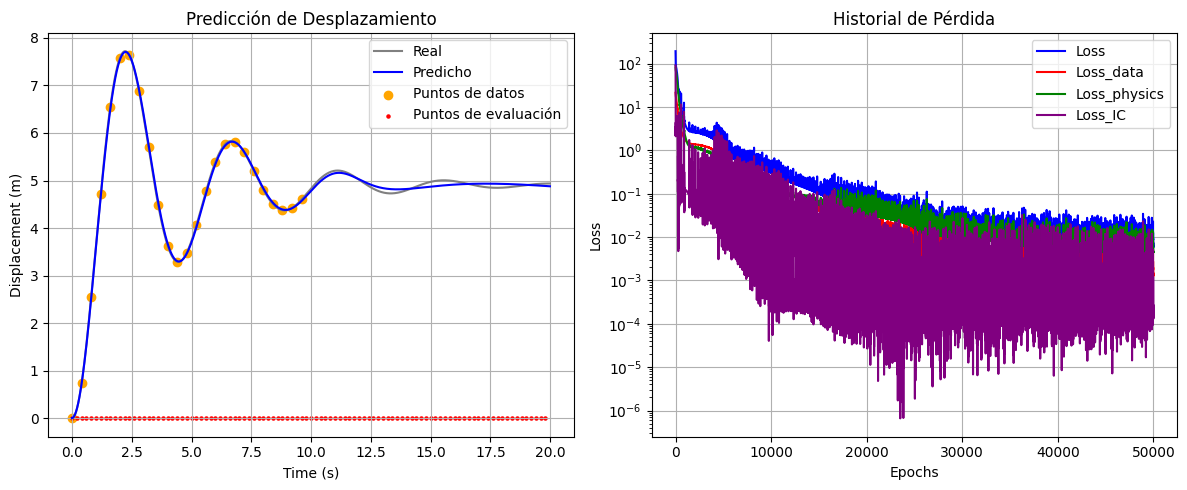

In [16]:
# Hacer predicciones
y_pred = model_pinn.dnn(X_test).detach().numpy()

# Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Predicción vs Real ---
axs[0].plot(X_test[:, 0].numpy(), y_test.numpy(), label='Real', linewidth=1.5, color = 'grey')
axs[0].plot(X_test[:, 0].numpy(), y_pred, label='Predicho', linewidth=1.5, color = 'blue')
axs[0].scatter(X_train[:, 0], y_train, color='orange', label='Puntos de datos', marker='o')
axs[0].scatter(X_collocation, np.zeros_like(X_collocation), color='red', label='Puntos de evaluación', marker= 'o', s=5)
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Displacement (m)')
axs[0].grid(True)
axs[0].set_title('Predicción de Desplazamiento')
axs[0].legend()

# --- Gráfico 2: Historial de pérdida ---
# plot y logaritmico
axs[1].semilogy(model_pinn.loss_history["Total"], label='Loss', color='blue', linewidth=1.5)
axs[1].semilogy(model_pinn.loss_history["Data"], label='Loss_data', color='red', linewidth=1.5)
axs[1].semilogy(model_pinn.loss_history["Physics"], label='Loss_physics', color='green', linewidth=1.5)
axs[1].semilogy(model_pinn.loss_history["IC"], label='Loss_IC', color='purple', linewidth=1.5)
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].grid(True)
axs[1].set_title('Historial de Pérdida')
axs[1].legend()

# Ajustar diseño para evitar superposiciones
plt.tight_layout()

# Mostrar los gráficos
plt.show()